# Классификация ботов

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from itertools import product
from lightgbm import LGBMClassifier
from metric import precision_at_recall, recall_at_fpr, pr_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [5]:
random_state = 42

### Подход к решению

1. Была проведена предобработка событий. Полные дубликаты событий были удалены, события упорядочены по времени внутри каждого `cookie_id`, а значения `platform` приведены к единому формату. Пропуски не заполнялись единым значением, поскольку для многих полей они имеют структурный характер. Для каждого `cookie_id` использовались только события, попадающие в соответствующее временное окно наблюдения.

2. Из последовательности событий были построены несколько групп поведенческих признаков:

- базовые признаки: общее количество событий и число уникальных объявлений;

-	временные признаки: статистики интервалов между последовательными событиями (mean, median, квантили, стандартное отклонение и другое), доли коротких интервалов;

- признаки разнообразия поведения: количество уникальных категорий, локаций, поисковых запросов и страниц поиска;

- признаки движения указателя: наличие координат указателя, доля событий с координатами, расстояния между последовательными позициями и разнообразие координат.

3. Для оценки качества использовалась основная метрика задачи `P@R>=0.7`. Так как тестовые данные относятся к более позднему отрезку времени, вместо случайного разбиения использовалась временная валидация: модель последовательно обучалась на предыдущих днях и проверялась на следующем дне. Для сравнения моделей учитывались среднее значение метрики по временным разбиениям, стандартное отклонение и минимальное значение. Такой подход позволяет оценивать не только среднее качество, но и устойчивость модели во времени.

4. Были сравнены несколько алгоритмов классификации: `RandomForest`, `CatBoost`, `LightGBM` и `XGBoost`.

## I. Загрузка и анализ данных

In [16]:
train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

print(train.shape, test.shape, events.shape)
print('доля ботов в train:', train.target.mean().round(4))
train.head()

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0811


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [17]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [18]:
print(events.event_name.value_counts())

event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081
Name: count, dtype: int64


In [19]:
print(events.platform.value_counts())

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64


In [20]:
print('Пропуски по колонкам:')
print(events.isna().mean().round(3), '\n')

Пропуски по колонкам:
cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64 



In [21]:
print('Количество уникальных значений:')
print(events.nunique().sort_values())

Количество уникальных значений:
seller_type           2
event_name           10
eid                  10
platform             11
item_category        15
item_location        40
search_page          46
search_query        120
user_agent          148
pointer_y          1081
pointer_x          1921
cookie_id         16000
item_id           53856
event_ts         285094
dtype: int64


## II. Проверка и предобработка данных




### i. Дубликаты

Исследуем данные на предмет полных дубликатов.

In [22]:
duplicates = events.duplicated().sum()

print('Количество полных дубликатов:', duplicates)

Количество полных дубликатов: 4863


In [23]:
duplicates = events[events.duplicated(keep=False)]
duplicates.sort_values(['cookie_id', 'event_ts', 'event_name']).head(20)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
37283,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
141860,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
314150,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
321075,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
10173,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
210391,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
24981,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN
102678,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN
80882,ck_00389b209b37394b,2026-04-15 07:51:32,900,captcha_shown,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244462,ck_00389b209b37394b,2026-04-15 07:51:32,900,captcha_shown,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
duplicate_groups = (
    events
    .groupby(list(events.columns), dropna=False)
    .size()
    .sort_values(ascending=False)
)

duplicate_groups.value_counts().sort_index()

,count
1,319179
2,4863


In [25]:
events = events.drop_duplicates().reset_index(drop=True)

print('Размер после удаления дубликатов:', events.shape)
print('Количество полных дубликатов:', events.duplicated().sum())

Размер после удаления дубликатов: (324042, 14)
Количество полных дубликатов: 0


Все дублирующиеся события встречаются ровно два раза и полностью совпадают по всем признакам. Такие повторы могут искусственно увеличивать количество событий и искажать временные признаки, поэтому полные дубликаты были удалены.

### ii. Порядок событий

События необходимо отсортировать по `cookie_id` и `event_ts`, чтобы дальнейший анализ временных признаков был корректен.

In [26]:
events = events.sort_values(['cookie_id', 'event_ts']).reset_index(drop=True)

### iii. Пропуски

In [27]:
events.groupby('event_name').apply(
    lambda x: x.isna().mean(),
    include_groups=False
).round(4)

,cookie_id,event_ts,eid,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,,,,,,
captcha_shown,0.0,0.0,0.0,0.0,0.0,1.0,1.0000,1.0000,1.0000,1.0,1.0,0.7283,0.7283
contact_chat_open,0.0,0.0,0.0,0.0,0.0,0.0,0.0582,0.0304,0.0847,1.0,1.0,0.6922,0.6922
contact_message_sent,0.0,0.0,0.0,0.0,0.0,0.0,0.0604,0.0284,0.0900,1.0,1.0,0.6774,0.6774
contact_phone_show,0.0,0.0,0.0,0.0,0.0,0.0,0.0589,0.0284,0.0939,1.0,1.0,0.6773,0.6773
favorite_add,0.0,0.0,0.0,0.0,0.0,0.0,0.0633,0.0278,0.0912,1.0,1.0,0.6506,0.6506
item_view,0.0,0.0,0.0,0.0,0.0,0.0,0.0594,0.0303,0.0902,1.0,1.0,0.6732,0.6732
login,0.0,0.0,0.0,0.0,0.0,1.0,1.0000,1.0000,1.0000,1.0,1.0,0.6454,0.6454
photo_swipe,0.0,0.0,0.0,0.0,0.0,0.0,0.0583,0.0319,0.0877,1.0,1.0,0.6580,0.6580
search_results_view,0.0,0.0,0.0,0.0,0.0,1.0,0.0596,0.0310,1.0000,0.0,0.0,0.6694,0.6694


Большинство пропусков определяются типом события. Отдельного анализа требуют пропуски в `item_category`, `item_location`, `seller_type` и `pointer_x`/`pointer_y`.

### iv. Категориальные признаки

In [28]:
events['platform'].value_counts()

,count
platform,
desktop,46157
WEB,45799
Web,45703
web,45284
ANDROID,41809
Android,41637
android,41542
iphone,4035
iOS,4035


Признак `platform` стоит нормализировать и привести к нижнему регистру. Категории `ios` и `iphone`, `web` и `desktop` потенциально могут обозначать одну и ту же платформу, это нужно проверить.

In [29]:
ios_ua = set(events.loc[events['platform'].str.lower() == 'ios', 'user_agent'])
iphone_ua = set(events.loc[events['platform'].str.lower() == 'iphone', 'user_agent'])

print('ios UA:', len(ios_ua))
print('iphone UA:', len(iphone_ua))
print('общих UA:', len(ios_ua & iphone_ua))

print(
    'доля ios UA, встречающихся в iphone:',
    len(ios_ua & iphone_ua) / len(ios_ua)
)

print(
    'доля iphone UA, встречающихся в ios:',
    len(ios_ua & iphone_ua) / len(iphone_ua)
)

ios UA: 9
iphone UA: 9
общих UA: 9
доля ios UA, встречающихся в iphone: 1.0
доля iphone UA, встречающихся в ios: 1.0


In [30]:
desktop_ua = set(events.loc[events['platform'].str.lower() == 'desktop', 'user_agent'])
web_ua = set(events.loc[events['platform'].str.lower() == 'web', 'user_agent'])

print('desktop UA:', len(desktop_ua))
print('web UA:', len(web_ua))
print('общих UA:', len(desktop_ua & web_ua))

print(
    'доля desktop UA, встречающихся в web:',
    len(desktop_ua & web_ua) / len(desktop_ua)
)

print(
    'доля web UA, встречающихся в desktop:',
    len(desktop_ua & web_ua) / len(web_ua)
)

desktop UA: 64
web UA: 64
общих UA: 64
доля desktop UA, встречающихся в web: 1.0
доля web UA, встречающихся в desktop: 1.0


Для `ios` и `iphone`, `web` и `desktop` наблюдаются одинаковые `user_agent`. Следовательно можно объединить их в одну категорию.

In [31]:
events['platform'] = events['platform'].str.lower().replace({
    'iphone': 'ios',
    'desktop': 'web'
})
events['platform'].value_counts()

,count
platform,
web,182943
android,124988
ios,16111


In [32]:
events['seller_type'].value_counts(dropna=False)

,count
seller_type,
NaN,131888
private,110955
pro,81199


In [33]:
events['item_category'].value_counts(dropna=False)

,count
item_category,
NaN,32458
avtomobili,20536
mebel,20236
bytovaya_tehnika,19861
hobbi,19731
elektronika,19711
uslugi,19586
odezhda,19559
kvartiry_arenda,19429


In [34]:
events['item_location'].value_counts(dropna=False)

,count
item_location,
sankt-peterburg,38579
novosibirsk,37447
moskva,37386
ekaterinburg,36732
NaN,23468
ryazan,4564
izhevsk,4522
barnaul,4479
astrahan,4453


In [35]:
events['search_query'].value_counts(dropna=False)

,count
search_query,
NaN,225113
кофемашина,907
toyota camry,906
renault logan,900
kia rio 2019,897
...,...
аккумулятор,750
стартер,747
macbook air m1,744


## III. Фильтрация событий по окну наблюдения

Признаки считаем только по событиям внутри окна: `window_start_ts <= event_ts < window_end_ts`.

In [36]:
def events_in_window(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

In [37]:
ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print(len(ev_tr), len(ev_te))

195484 88349


## IV. Валидация

Поскольку тестовая выборка относится к более позднему временному периоду, для валидации используется временное разбиение обучающей выборки. В качестве валидационной части используются наиболее поздние наблюдения, что позволяет приблизить условия оценки к условиям тестирования.


In [38]:
def validate_model(
    model,
    X,
    y,
    is_valid,
    cols,
    plot=True
):

  model.fit(
      X.loc[~is_valid, cols],
      y[~is_valid]
  )

  prediction = model.predict_proba(
      X.loc[is_valid, cols]
  )[:, 1]

  p_at_r = precision_at_recall(
      y[is_valid],
      prediction
  )

  r_at_fpr = recall_at_fpr(
      y[is_valid],
      prediction
  )

  if plot:

      precision, recall = pr_curve(
            y[is_valid],
            prediction
      )

      plt.figure(figsize=(7, 5))
      plt.plot(recall, precision)
      plt.axvline(
          0.7,
          linestyle='--',
          label='Recall = 0.70'
      )

      mask = recall >= 0.7
      best_idx = np.where(mask)[0][
          np.argmax(precision[mask])
      ]

      plt.scatter(
          recall[best_idx],
          precision[best_idx],
          s=30,
          zorder=3,
          label=f'P@R≥0.70 = {p_at_r:.3f}'
      )

      plt.xlabel('Recall')
      plt.ylabel('Precision')
      plt.grid(alpha=0.3)
      plt.legend()
      plt.show()

  return p_at_r, r_at_fpr

Для более надежной и устойчивой оценки качества модели используем дополнительно валидацию на нескольких последовательных временных периодах. Модель последовательно проверяется на пяти последних днях, при этом для каждого дня обучение проводится только на предшествующих данных. Для оценки устойчивости рассчитываются среднее значение метрики, стандартное отклонение и минимальное значение метрики.

In [39]:
def validate_temporal(
    model,
    X,
    y,
    cols
):
    dates = train['window_start_ts'].dt.normalize()

    scores = []

    for date in pd.to_datetime([
        '2026-04-15',
        '2026-04-16',
        '2026-04-17',
        '2026-04-18',
        '2026-04-19'
    ]):

        is_train = (dates < date).values
        is_valid = (dates == date).values

        model.fit(
            X.loc[is_train, cols],
            y[is_train]
        )

        prediction = model.predict_proba(
            X.loc[is_valid, cols]
        )[:, 1]

        p_at_r = precision_at_recall(
            y[is_valid],
            prediction
        )

        scores.append(p_at_r)

    return (
        np.mean(scores),
        np.std(scores, ddof=1),
        np.min(scores)
    )

## V. Анализ поведения и построение признаков

In [40]:
ev_for_analysis = ev_tr.merge(
    train[['cookie_id', 'target']],
    on='cookie_id',
    how='left'
)

ev_for_analysis.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,window_start_ts,window_end_ts,target
0,ck_000c95f1408dcb00,2026-04-19 14:49:54,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,hobbi,NaN,NaN,гитара акустическая,2.0,373.0,1059.0,2026-04-19,2026-04-20,0
1,ck_000c95f1408dcb00,2026-04-19 14:50:17,210,photo_swipe,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1021247.0,mebel,samara,private,NaN,NaN,1419.0,674.0,2026-04-19,2026-04-20,0
2,ck_000c95f1408dcb00,2026-04-19 15:50:21,200,item_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1021247.0,mebel,samara,private,NaN,NaN,1224.0,218.0,2026-04-19,2026-04-20,0
3,ck_000c95f1408dcb00,2026-04-19 15:50:47,200,item_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1050338.0,mebel,volgograd,private,NaN,NaN,1195.0,372.0,2026-04-19,2026-04-20,0
4,ck_000c95f1408dcb00,2026-04-19 15:51:45,200,item_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1050338.0,NaN,volgograd,private,NaN,NaN,898.0,1021.0,2026-04-19,2026-04-20,0


### i. Baseline

#### Простейшие признаки

In [41]:
def basic_features(ev, meta):
    g = ev.groupby('cookie_id')
    f = pd.DataFrame({
        'n_events': g.size(),
        'item_nunique': g.item_id.nunique(),
    })
    f = meta[['cookie_id']].merge(f.reset_index(), on='cookie_id', how='left')
    return f.fillna(0)

Xtr = basic_features(ev_tr, train)
Xte = basic_features(ev_te, test)
ytr = train.target.values
Xtr.head()

,cookie_id,n_events,item_nunique
0,ck_54a059eb7d3ea68b,7,4
1,ck_7e4de46eeab82974,41,19
2,ck_9320229ef6304522,36,19
3,ck_30ccd25bc1714ed9,21,10
4,ck_a77c5f05948cdeef,28,16


#### Валидация

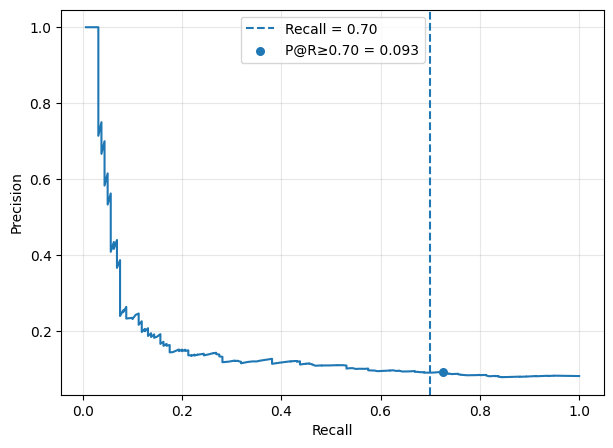

P@R>=0.7: 0.0931
R@FPR<=0.01: 0.0688
Mean P@R>=0.7: 0.0999
Std P@R>=0.7: 0.0152
Min P@R>=0.7: 0.0823


In [42]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = ['n_events', 'item_nunique']

model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=random_state
)

p_at_r, r_at_fpr = validate_model(
    model,
    Xtr,
    ytr,
    is_valid,
    cols
)

print('P@R>=0.7:', round(p_at_r, 4))
print('R@FPR<=0.01:', round(r_at_fpr, 4))

mean_score, std_score, min_score = validate_temporal(
    model,
    Xtr,
    ytr,
    cols
)

print('Mean P@R>=0.7:', round(mean_score, 4))
print('Std P@R>=0.7:', round(std_score, 4))
print('Min P@R>=0.7:', round(min_score, 4))

### ii. Временной анализ



#### Интервалы между событиями

Автоматизированный трафик может отличаться от человеческого скоростью взаимодействия. Проверим эту гипотезу.

In [43]:
ev_time = ev_for_analysis.sort_values(
    ['cookie_id', 'event_ts']
)

ev_time['dt'] = (
    ev_time.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()
)

In [44]:
ev_time.groupby('target')['dt'].describe(
    percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]
)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,,,,
0,159187.0,744.081156,1904.809192,0.0,1.0,4.0,8.0,20.0,47.0,120.0,3185.4,6043.0,8459.00,9760.0
1,25206.0,430.948108,1489.721885,0.0,2.0,4.0,5.0,7.0,14.0,35.0,404.0,3992.5,7970.25,9608.0


У автоматизированного трафика интервалы между событиями в среднем оказались действительно меньше. Проверим гипотезу после агрегации по `cookie_id`.

In [45]:
time_stats = (
    ev_time.groupby(['cookie_id', 'target']).agg(
        dt_mean=('dt', 'mean'),
        dt_median=('dt', 'median'),
        dt_std=('dt', 'std'),
        dt_min=('dt', 'min'),
        dt_max=('dt', 'max'),
        dt_q10=('dt', lambda x: x.quantile(0.10)),
        dt_q25=('dt', lambda x: x.quantile(0.25)),
        dt_q75=('dt', lambda x: x.quantile(0.75)),
        dt_q90=('dt', lambda x: x.quantile(0.90)),
        dt_unique_ratio=('dt', lambda x: x.nunique() / x.notna().sum()
                        if x.notna().sum() > 0 else np.nan)
    ).reset_index()
)

time_stats['dt_iqr'] = (
    time_stats['dt_q75'] - time_stats['dt_q25']
)

time_stats['dt_cv'] = (
    time_stats['dt_std'] / (time_stats['dt_mean'] + 1e-6)
)

time_stats.groupby('target')[
    ['dt_mean',
     'dt_median',
     'dt_std',
     'dt_min',
     'dt_max',
     'dt_q10',
     'dt_q25',
     'dt_q75',
     'dt_q90',
     'dt_unique_ratio',
     'dt_iqr',
     'dt_cv']
].median()

,dt_mean,dt_median,dt_std,dt_min,dt_max,dt_q10,dt_q25,dt_q75,dt_q90,dt_unique_ratio,dt_iqr,dt_cv
target,,,,,,,,,,,,
0,670.692308,60.5,1751.054621,7.0,5894.0,17.0,30.5,128.000,1619.0,1.000000,85.75,2.044688
1,429.714286,25.0,1378.387444,5.0,6053.0,9.2,15.0,42.375,129.7,0.866667,25.00,2.596203


Гипотеза подтвердилась и после агрегации. Боты выполняют последовательные действия быстрее людей, это видно особенно хорошо по квантилям. Используем эти признаки далее при обучении.

#### Доля коротких временных интервалов

Посчитаем для каждого `cookie_id` долю последовательных действий, временные интервалы между которыми не превышают 1, 5, 10, 30, 60 секунд. Проверим гипотезу о том, что доля коротких временных интервалов у ботов в среднем выше.

In [46]:
for sec in [1, 5, 10, 30, 60]:
    ev_time[f'dt_le_{sec}'] = (ev_time['dt'] <= sec).astype(int)

In [47]:
time_stats = time_stats.merge(
    ev_time.groupby('cookie_id').agg(
        prop_dt_le_1=('dt_le_1', 'mean'),
        prop_dt_le_5=('dt_le_5', 'mean'),
        prop_dt_le_10=('dt_le_10', 'mean'),
        prop_dt_le_30=('dt_le_30', 'mean'),
        prop_dt_le_60=('dt_le_60', 'mean'),
    )
    .reset_index(),
    on='cookie_id',
    how='left'
)

time_stats.groupby('target')[
    ['prop_dt_le_1',
     'prop_dt_le_5',
     'prop_dt_le_10',
     'prop_dt_le_30',
     'prop_dt_le_60']
].median()

,prop_dt_le_1,prop_dt_le_5,prop_dt_le_10,prop_dt_le_30,prop_dt_le_60
target,,,,,
0,0.0,0.000000,0.066667,0.250000,0.450000
1,0.0,0.035714,0.153846,0.545455,0.791667


Гипотеза подтверждается. Наиболее заметное различие между ботами и реальными пользователями наблюдается для интервалов до 30 и 60 секунд.

#### Временные признаки

In [48]:
for col in time_stats.columns[2:]:
    print(col)

dt_mean
dt_median
dt_std
dt_min
dt_max
dt_q10
dt_q25
dt_q75
dt_q90
dt_unique_ratio
dt_iqr
dt_cv
prop_dt_le_1
prop_dt_le_5
prop_dt_le_10
prop_dt_le_30
prop_dt_le_60


In [49]:
def time_features(ev, meta):
    ev = ev.sort_values(['cookie_id', 'event_ts']).copy()

    ev['dt'] = (
        ev.groupby('cookie_id')['event_ts']
        .diff()
        .dt.total_seconds()
    )

    g = ev.groupby('cookie_id')

    f = g['dt'].agg(
        dt_mean='mean',
        dt_median='median',
        dt_std='std',
        dt_min='min',
        dt_max='max',
    )

    f['dt_q25'] = g['dt'].quantile(0.25)
    f['dt_q75'] = g['dt'].quantile(0.75)
    f['dt_q90'] = g['dt'].quantile(0.90)
    f['dt_q10'] = g['dt'].quantile(0.10)

    f['dt_iqr'] = (
        f['dt_q75'] - f['dt_q25']
    )

    f['dt_cv'] = (
        f['dt_std'] / (f['dt_mean'] + 1e-6)
    )

    f['dt_unique_ratio'] = g['dt'].apply(
        lambda x: x.nunique() / x.notna().sum()
        if x.notna().sum() > 0 else np.nan
    )

    for sec in [1, 5, 10, 30, 60]:
        col = f'prop_dt_le_{sec}'

        f[col] = (
            ev.loc[ev['dt'].notna()]
            .assign(short=lambda x: (x['dt'] <= sec).astype(float))
            .groupby('cookie_id')['short']
            .mean()
        )

    f = f.reset_index()

    f = (
        meta[['cookie_id']]
        .merge(f, on='cookie_id', how='left')
    )

    return f

Xtr_time = Xtr.merge(
    time_features(ev_tr, train),
    on='cookie_id',
    how='left'
)

Xte_time = Xte.merge(
    time_features(ev_te, test),
    on='cookie_id',
    how='left'
)

ytr_time = train.target.values
Xtr_time.head()

,cookie_id,n_events,item_nunique,dt_mean,dt_median,dt_std,dt_min,dt_max,dt_q25,dt_q75,dt_q90,dt_q10,dt_iqr,dt_cv,dt_unique_ratio,prop_dt_le_1,prop_dt_le_5,prop_dt_le_10,prop_dt_le_30,prop_dt_le_60
0,ck_54a059eb7d3ea68b,7,4,27.833333,21.0,29.949402,1.0,84.0,9.50,31.00,59.0,3.5,21.50,1.076026,1.000000,0.166667,0.166667,0.333333,0.666667,0.833333
1,ck_7e4de46eeab82974,41,19,986.900000,57.5,2416.286861,2.0,8511.0,19.00,82.25,3889.7,6.9,63.25,2.448360,0.900000,0.000000,0.075000,0.200000,0.325000,0.525000
2,ck_9320229ef6304522,36,19,1042.600000,22.0,2306.449400,1.0,8350.0,14.50,73.00,4513.4,4.8,58.50,2.212209,0.771429,0.028571,0.114286,0.171429,0.600000,0.714286
3,ck_30ccd25bc1714ed9,21,10,861.050000,54.5,2502.081501,6.0,8604.0,37.25,70.00,877.9,17.9,32.75,2.905849,0.900000,0.000000,0.000000,0.050000,0.250000,0.600000
4,ck_a77c5f05948cdeef,28,16,707.333333,52.0,1748.439172,22.0,7224.0,32.50,106.50,2743.2,28.6,74.00,2.471874,0.962963,0.000000,0.000000,0.000000,0.185185,0.518519


#### Валидация


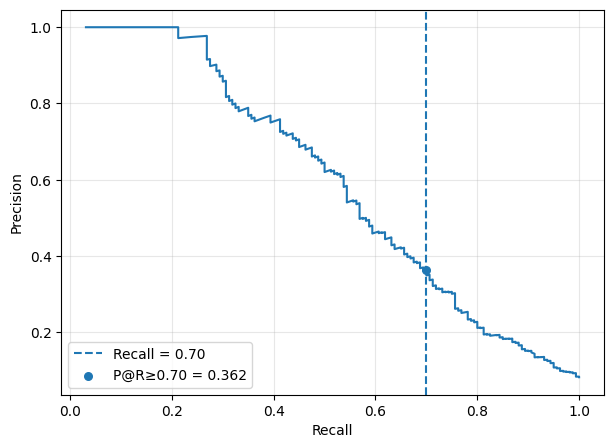

P@R>=0.7: 0.3625
R@FPR<=0.01: 0.3563
Mean P@R>=0.7: 0.3502
Std P@R>=0.7: 0.0735
Min P@R>=0.7: 0.2781


In [50]:
is_valid = train.window_start_ts.ge('2026-04-17').values
time_cols = [col for col in time_stats.columns[2:]]

model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=random_state
)

p_at_r, r_at_fpr = validate_model(
    model,
    Xtr_time,
    ytr_time,
    is_valid,
    time_cols + cols
)

print('P@R>=0.7:', round(p_at_r, 4))
print('R@FPR<=0.01:', round(r_at_fpr, 4))

mean_score, std_score, min_score = validate_temporal(
    model,
    Xtr_time,
    ytr_time,
    time_cols + cols
)

print('Mean P@R>=0.7:', round(mean_score, 4))
print('Std P@R>=0.7:', round(std_score, 4))
print('Min P@R>=0.7:', round(min_score, 4))

### iii. Разнообразие контента



#### Разнообразие просматриваемого контента

Боты могут просматривать больше уникальных объявлений и категорий. Реальные пользователи чаще преследуют конкретную цель и поэтому могут концентрироваться на меньшем числе категорий. Проверим эту гипотезу.

In [51]:
diversity_stats = (
    ev_for_analysis.groupby(['cookie_id', 'target']).agg(
        item_nunique=('item_id', 'nunique'),
        category_nunique=('item_category', 'nunique'),
        query_nunique=('search_query', 'nunique'),
        search_page_nunique=('search_page', 'nunique')
    )
    .reset_index()
)

In [52]:
diversity_cols = [
    'item_nunique',
    'category_nunique',
    'query_nunique',
    'search_page_nunique'
]

for col in diversity_cols:
    print(f'\n{col}')

    display(diversity_stats.groupby('target')[col]
        .describe(percentiles=[.25, .5, .75, .9, .95, .99])
    )


item_nunique


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,10192.0,8.917190,9.018032,0.0,3.0,6.0,12.0,20.0,27.0,44.00,80.0
1,899.0,13.779755,10.983506,1.0,6.0,10.0,18.0,29.0,37.0,49.02,70.0



category_nunique


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,10192.0,2.281201,1.257226,0.0,1.0,2.0,3.0,4.0,5.0,6.0,8.0
1,899.0,1.787542,0.814963,0.0,1.0,2.0,2.0,3.0,3.0,4.0,6.0



query_nunique


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,10192.0,3.789835,3.200398,0.0,1.0,3.0,5.0,8.0,10.0,15.0,29.0
1,899.0,4.758621,3.142606,0.0,2.0,4.0,7.0,9.0,11.0,14.0,17.0



search_page_nunique


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,10192.0,2.627060,1.859912,0.0,1.0,2.0,4.0,5.0,6.0,8.0,11.0
1,899.0,4.982202,4.011636,0.0,2.0,4.0,7.0,11.0,14.0,19.0,23.0


Гипотеза подтвердилась частично. Боты в среднем просматривают большее количество объявлений, но концентрируются на ограниченном наборе категорий.

In [53]:
diversity_stats['items_per_category'] = (
    diversity_stats['item_nunique'] /
    diversity_stats['category_nunique'].replace(0, np.nan)
)

In [54]:
diversity_stats = diversity_stats.merge(
    ev_for_analysis.groupby('cookie_id').agg(
        item_events=('item_id', 'count')
    )
    .reset_index(),
    on='cookie_id',
    how='left'
)

diversity_stats.groupby('target')['items_per_category'].describe(
    percentiles=[.25, .5, .75, .9, .95, .99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,10157.0,3.958187,3.397783,0.000000,1.75,3.0,5.0,8.0,10.5,16.703333,40.0
1,897.0,8.944575,8.181895,0.333333,3.50,6.0,12.0,19.0,26.0,38.080000,53.0


Признак `items_per_category` показывает, что боты в среднем просматривают больше уникальных объявлений в рамках одной категории. Это также может помочь при обучении.

#### Географическое разнообразие объявлений

Боты могут просматривать объявления из большего числа локаций, а ркальные пользователи обычно ищут объявления, географически ограничивающиеся интересующим их регионов.

In [55]:
diversity_stats = diversity_stats.merge(
    ev_for_analysis.groupby('cookie_id').agg(
        location_nunique=('item_location', 'nunique')
    )
    .reset_index(),
    on='cookie_id',
    how='left'
)

diversity_stats.groupby('target')['location_nunique'].describe(
    percentiles=[.25, .5, .75, .9, .95, .99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,10192.0,5.881868,4.637013,0.0,2.0,5.0,8.0,12.0,15.0,22.0,30.0
1,899.0,9.789766,6.068215,1.0,5.0,8.0,14.0,19.0,21.1,28.0,31.0


Гипотеза подтверждается.

#### Повторяемость поисковых запросов

Боты могут чаще повторять одни и те же запросы. Проверим долю уникальных поисковых запросов для каждой `cookie_id`.

In [56]:
query_stats = (
    ev_for_analysis
    .groupby(['cookie_id', 'target']).agg(
        query_events=('search_query', 'count'),
        query_nunique=('search_query', 'nunique')
    )
    .reset_index()
)

diversity_stats['query_unique_ratio'] = (
    query_stats['query_nunique'] /
    query_stats['query_events'].replace(0, np.nan)
)

diversity_stats['query_events'] = query_stats['query_events']

In [57]:
diversity_stats.groupby('target')['query_unique_ratio'].describe(
    percentiles=[.25, .5, .75, .9, .95, .99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,9308.0,0.850212,0.186468,0.133333,0.714286,1.000000,1.0,1.0,1.0,1.0,1.0
1,862.0,0.660122,0.263920,0.125000,0.444444,0.666667,1.0,1.0,1.0,1.0,1.0


In [58]:
diversity_stats.groupby('target')['query_events'].describe(
    percentiles=[.25, .5, .75, .9, .95, .99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,10192.0,5.065640,5.124675,0.0,2.0,4.0,7.0,12.0,15.45,24.00,44.0
1,899.0,10.208009,10.849759,0.0,3.0,7.0,13.0,25.0,32.00,51.02,64.0


Боты имеют более высокую и повторяющуюся поисковую активность. Они совершают больше поисковых запросов и чаще их повторяют.

#### Признаки разнообразия контента

In [59]:
for col in diversity_stats.columns[2:]:
    print(col)

item_nunique
category_nunique
query_nunique
search_page_nunique
items_per_category
item_events
location_nunique
query_unique_ratio
query_events


In [60]:
diversity_stats.drop(columns=['item_events', 'item_nunique'], inplace=True)

In [61]:
def diversity_features(ev, meta):
    g = ev.groupby('cookie_id')

    f = g.agg(
        category_nunique=('item_category', 'nunique'),
        query_nunique=('search_query', 'nunique'),
        search_page_nunique=('search_page', 'nunique'),
        location_nunique=('item_location', 'nunique'),
        search_page_max=('search_page', 'max'),
        search_page_mean=('search_page', 'mean'),
        search_page_median=('search_page', 'median'),
        query_events=('search_query', 'count'),
    ).reset_index()

    item_stats = (
        g.agg(
            item_nunique=('item_id', 'nunique')
        )
        .reset_index()
    )

    f = f.merge(
        item_stats,
        on='cookie_id',
        how='left'
    )

    f['items_per_category'] = (
        f['item_nunique'] /
        f['category_nunique'].replace(0, np.nan)
    )

    f['query_unique_ratio'] = (
        f['query_nunique'] /
        f['query_events'].replace(0, np.nan)
    )

    f = f.drop(columns='item_nunique')

    f = (
        meta[['cookie_id']]
        .merge(f, on='cookie_id', how='left')
    )

    return f

Xtr_diversity = Xtr_time.merge(
    diversity_features(ev_tr, train),
    on='cookie_id',
    how='left'
)

Xte_diversity = Xte_time.merge(
    diversity_features(ev_te, test),
    on='cookie_id',
    how='left'
)

ytr_diversity = train.target.values

Xtr_diversity.head()

,cookie_id,n_events,item_nunique,dt_mean,dt_median,dt_std,dt_min,dt_max,dt_q25,dt_q75,...,category_nunique,query_nunique,search_page_nunique,location_nunique,search_page_max,search_page_mean,search_page_median,query_events,items_per_category,query_unique_ratio
0,ck_54a059eb7d3ea68b,7,4,27.833333,21.0,29.949402,1.0,84.0,9.50,31.00,...,3,3,3,5,6.0,3.000000,2.0,3,1.333333,1.000000
1,ck_7e4de46eeab82974,41,19,986.900000,57.5,2416.286861,2.0,8511.0,19.00,82.25,...,1,5,6,12,8.0,3.625000,3.5,8,19.000000,0.625000
2,ck_9320229ef6304522,36,19,1042.600000,22.0,2306.449400,1.0,8350.0,14.50,73.00,...,7,10,7,9,10.0,3.538462,2.0,13,2.714286,0.769231
3,ck_30ccd25bc1714ed9,21,10,861.050000,54.5,2502.081501,6.0,8604.0,37.25,70.00,...,1,3,2,4,2.0,1.666667,2.0,3,10.000000,1.000000
4,ck_a77c5f05948cdeef,28,16,707.333333,52.0,1748.439172,22.0,7224.0,32.50,106.50,...,4,6,4,6,7.0,2.833333,2.0,6,4.000000,1.000000


#### Валидация

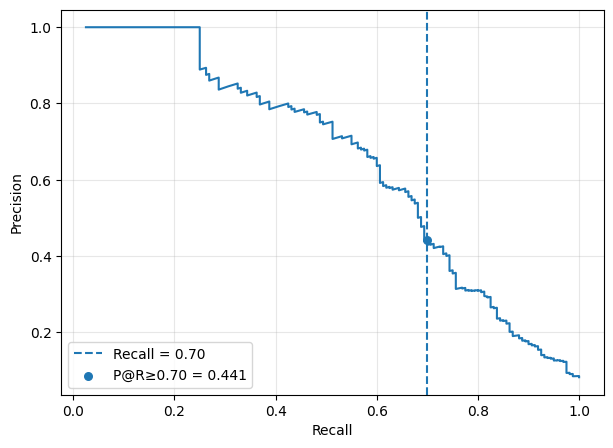

P@R>=0.7: 0.4409
R@FPR<=0.01: 0.425
Mean P@R>=0.7: 0.4607
Std P@R>=0.7: 0.1113
Min P@R>=0.7: 0.35


In [62]:
is_valid = train.window_start_ts.ge('2026-04-17').values
diversity_cols = [
    'category_nunique',
    'query_nunique',
    'search_page_nunique',
    'location_nunique',
    'search_page_max',
    'search_page_mean',
    'search_page_median',
    'query_events',
    'items_per_category',
    'query_unique_ratio',
]

model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=random_state
)

p_at_r, r_at_fpr = validate_model(
    model,
    Xtr_diversity,
    ytr_diversity,
    is_valid,
    diversity_cols + time_cols + cols
)

print('P@R>=0.7:', round(p_at_r, 4))
print('R@FPR<=0.01:', round(r_at_fpr, 4))

mean_score, std_score, min_score = validate_temporal(
    model,
    Xtr_diversity,
    ytr_diversity,
    diversity_cols + time_cols + cols
)

print('Mean P@R>=0.7:', round(mean_score, 4))
print('Std P@R>=0.7:', round(std_score, 4))
print('Min P@R>=0.7:', round(min_score, 4))

### iv. Координаты указателя в web версиях

Координаты указателя могут отражать характер взаимодействия пользователя с интерфейсом. Проверим для каких платформ доступны эти данные и отличается ли частота их встречаемости у пользователей и ботов.

In [63]:
pointer_by_platform = (
    ev_for_analysis.assign(
        pointer_present=(
            ev_for_analysis['pointer_x'].notna() &
            ev_for_analysis['pointer_y'].notna()
        )
    )
    .groupby(['platform', 'target'])['pointer_present']
    .agg(['mean', 'count'])
)

pointer_by_platform

mean  count
platform target                 
android  0       0.000000  70700
         1       0.000000   6126
ios      0       0.000000   9733
         1       0.000000    543
web      0       0.661829  88946
         1       0.330109  19436

Ожидаемо, координаты указателя встречаются только в веб-версиях приложения. Пропуски для ботов встречаются чаще, чем для реальных пользователей. Далее будем рассматривать только веб-платформы.

#### Отсутствие пропуска в веб-версии

Проверим гипотезу: данные об указателях чаще всего пропущены у ботов.

In [64]:
pointer_ev = ev_for_analysis[ev_for_analysis['platform'] == 'web'].copy()

pointer_ev['pointer_present'] = (
    pointer_ev['pointer_x'].notna() &
    pointer_ev['pointer_y'].notna()
)

pointer_stats = (
    pointer_ev
    .groupby(['cookie_id', 'target']).agg(
        pointer_present_ratio=('pointer_present', 'mean'),
        pointer_events=('pointer_present', 'sum')
    )
    .reset_index()
)

pointer_stats.groupby('target')['pointer_present_ratio'].describe(
    percentiles=[.25, .5, .75, .9, .95, .99]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,5329.0,0.676310,0.435248,0.0,0.0,0.933333,1.000000,1.0,1.0,1.0,1.0
1,588.0,0.405848,0.472188,0.0,0.0,0.000000,0.949525,1.0,1.0,1.0,1.0


У реальных пользователей координаты указателя присутствуют значительно чаще. Медианная доля таких событий составляет 0.93, тогда как у ботов 0. Наличие координат указателя может быть информативным признаком для классификации ботов. Добавим следующие бинарные признаки: наличие координат хотя бы в одном событии и наличие координат во всех событиях.

In [65]:
pointer_stats['pointer_any'] = (
    pointer_stats['pointer_present_ratio'] > 0
).astype(int)

pointer_stats['pointer_all'] = (
    pointer_stats['pointer_present_ratio'] == 1
).astype(int)

pointer_stats.groupby('target')[
    ['pointer_any', 'pointer_all']
].mean()

,pointer_any,pointer_all
target,,
0,0.712141,0.376431
1,0.426871,0.171769


#### Движение указателя

При наличии координат указателя можно анализировать изменение его положения между последовательными событиями. Неестественные перемещения или повторяющиеся координаты могут говорить о том, что пользователь является ботом. Проверим эту гипотезу.

In [66]:
pointer_move = (
    ev_for_analysis[
        (ev_for_analysis['platform'] == 'web') &
        ev_for_analysis['pointer_x'].notna() &
        ev_for_analysis['pointer_y'].notna()
    ]
    .sort_values(['cookie_id', 'event_ts'])
    .copy()
)

pointer_move['dx'] = pointer_move.groupby('cookie_id')['pointer_x'].diff()
pointer_move['dy'] = pointer_move.groupby('cookie_id')['pointer_y'].diff()
pointer_move['distance'] = np.sqrt(pointer_move['dx'] ** 2 + pointer_move['dy'] ** 2)

In [67]:
pointer_move_stats = (
    pointer_move
    .groupby(['cookie_id', 'target']).agg(
        pointer_distance_mean=('distance', 'mean'),
        pointer_distance_median=('distance', 'median'),
        pointer_distance_std=('distance', 'std'),
        pointer_x_nunique=('pointer_x', 'nunique'),
        pointer_y_nunique=('pointer_y', 'nunique')
    )
    .reset_index()
)

for col in pointer_move_stats.columns[2:]:
    print(f'\n{col}')
    display(
        pointer_move_stats.groupby('target')[col].describe(
            percentiles=[.25, .5, .75, .9, .95, .99]
        )
    )


pointer_distance_mean


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,3672.0,799.507628,196.899071,30.072138,699.351747,791.401310,890.931438,1023.303417,1129.394436,1397.742185,1768.857541
1,250.0,380.652468,195.209184,19.659917,243.667278,368.763251,496.733069,615.441428,749.300988,909.820599,1012.686032



pointer_distance_median


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,3672.0,771.365987,225.798378,32.557641,640.526226,758.189268,879.466065,1047.900291,1165.366413,1492.274946,1768.857541
1,250.0,368.961370,200.169569,13.928388,232.145194,354.122130,471.398144,620.317355,760.154767,925.707138,1012.800079



pointer_distance_std


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,3506.0,390.534460,123.817783,2.456781,329.667220,398.517877,456.227806,523.329874,570.594604,723.668928,1080.692180
1,248.0,184.011814,99.284474,12.283444,110.981851,178.410261,243.606203,300.287539,344.383682,475.368690,572.877168



pointer_x_nunique


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,3795.0,15.388142,15.061229,1.0,5.0,10.0,20.0,34.0,46.0,74.0,116.0
1,251.0,23.764940,20.709334,1.0,10.0,18.0,29.5,52.0,72.0,96.5,117.0



pointer_y_nunique


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
target,,,,,,,,,,,
0,3795.0,15.278261,14.821217,1.0,5.0,10.0,20.0,34.0,45.0,72.06,116.0
1,251.0,23.266932,20.643170,1.0,9.0,17.0,29.0,48.0,72.5,94.50,112.0


Характер переещения указателя значительно различается между классами и является информативным признаком. У реальных пользователей среднее и медианное расстояния между последовательными положениями указателя примерно в два раза выше, чем у ботов.

In [68]:
pointer_coord_stats = (
    pointer_move
    .groupby(['cookie_id', 'target']).agg(
        pointer_events=('pointer_x', 'count'),
        pointer_x_nunique=('pointer_x', 'nunique'),
        pointer_y_nunique=('pointer_y', 'nunique')
    )
    .reset_index()
)

pointer_coord_stats['pointer_x_unique_ratio'] = (
    pointer_coord_stats['pointer_x_nunique'] /
    pointer_coord_stats['pointer_events']
)

pointer_coord_stats['pointer_y_unique_ratio'] = (
    pointer_coord_stats['pointer_y_nunique'] /
    pointer_coord_stats['pointer_events']
)

pointer_coord_stats.groupby('target')[
    ['pointer_x_unique_ratio', 'pointer_y_unique_ratio']
].describe(
    percentiles=[.25, .5, .75, .9, .95, .99]
)

pointer_x_unique_ratio                                               \
                        count      mean       std       min       25%  50%   
target                                                                       
0                      3795.0  0.995913  0.017554  0.666667  1.000000  1.0   
1                       251.0  0.960938  0.066181  0.563910  0.943174  1.0   

                            ... pointer_y_unique_ratio                      \
        75%  90%  95%  99%  ...                   mean       std       min   
target                      ...                                              
0       1.0  1.0  1.0  1.0  ...               0.992653  0.022392  0.666667   
1       1.0  1.0  1.0  1.0  ...               0.937651  0.080467  0.586466   

                                                     
             25%       50%  75%  90%  95%  99%  max  
target                                               
0       1.000000  1.000000  1.0  1.0  1.0  1.0  1.0  
1       0.903361  0.962963  1.0  1.0  1.0  1.0  1.0  

[2 rows x 22 columns]

У реальных пользователей доля уникальных координат несколько выше, чем у ботов. Это может указывать на более повторяющиеся положения указателя у ботов.

#### Признаки координат указателя

In [69]:
def pointer_features(ev, meta):
    p = ev[
        ev['platform'].eq('web')
    ].copy()

    p['pointer_present'] = (
        p['pointer_x'].notna() &
        p['pointer_y'].notna()
    )

    f = (
        p.groupby('cookie_id')
        .agg(
            pointer_present_ratio=('pointer_present', 'mean'),
            pointer_any=('pointer_present', 'any'),
            pointer_all=('pointer_present', 'all'),
        )
        .reset_index()
    )

    f['pointer_any'] = f['pointer_any'].astype(int)
    f['pointer_all'] = f['pointer_all'].astype(int)

    pm = (
        p[p['pointer_present']]
        .sort_values(['cookie_id', 'event_ts'])
        .copy()
    )

    pm['dx'] = (
        pm.groupby('cookie_id')['pointer_x'].diff()
    )

    pm['dy'] = (
        pm.groupby('cookie_id')['pointer_y'].diff()
    )

    pm['distance'] = np.sqrt(
        pm['dx'] ** 2 +
        pm['dy'] ** 2
    )

    move_stats = (
        pm.groupby('cookie_id')
        .agg(
            pointer_distance_mean=('distance', 'mean'),
            pointer_distance_median=('distance', 'median'),
            pointer_distance_std=('distance', 'std'),
            pointer_events=('pointer_x', 'count'),
            pointer_x_nunique=('pointer_x', 'nunique'),
            pointer_y_nunique=('pointer_y', 'nunique'),
        )
        .reset_index()
    )

    move_stats['pointer_x_unique_ratio'] = (
        move_stats['pointer_x_nunique'] /
        move_stats['pointer_events'].replace(0, np.nan)
    )

    move_stats['pointer_y_unique_ratio'] = (
        move_stats['pointer_y_nunique'] /
        move_stats['pointer_events'].replace(0, np.nan)
    )

    move_stats = move_stats.drop(
        columns=[
            'pointer_events',
            'pointer_x_nunique',
            'pointer_y_nunique'
        ]
    )

    f = f.merge(
        move_stats,
        on='cookie_id',
        how='left'
    )

    f = (
        meta[['cookie_id']]
        .merge(f, on='cookie_id', how='left')
    )

    return f


Xtr_pointer = Xtr_diversity.merge(
    pointer_features(ev_tr, train),
    on='cookie_id',
    how='left'
)

Xte_pointer = Xte_diversity.merge(
    pointer_features(ev_te, test),
    on='cookie_id',
    how='left'
)

ytr_pointer = train.target.values

Xtr_pointer.head()

,cookie_id,n_events,item_nunique,dt_mean,dt_median,dt_std,dt_min,dt_max,dt_q25,dt_q75,...,items_per_category,query_unique_ratio,pointer_present_ratio,pointer_any,pointer_all,pointer_distance_mean,pointer_distance_median,pointer_distance_std,pointer_x_unique_ratio,pointer_y_unique_ratio
0,ck_54a059eb7d3ea68b,7,4,27.833333,21.0,29.949402,1.0,84.0,9.50,31.00,...,1.333333,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ck_7e4de46eeab82974,41,19,986.900000,57.5,2416.286861,2.0,8511.0,19.00,82.25,...,19.000000,0.625000,0.926829,1.0,0.0,660.463913,659.794665,376.363430,0.947368,1.0
2,ck_9320229ef6304522,36,19,1042.600000,22.0,2306.449400,1.0,8350.0,14.50,73.00,...,2.714286,0.769231,0.972222,1.0,0.0,967.224037,855.446249,417.724917,1.000000,1.0
3,ck_30ccd25bc1714ed9,21,10,861.050000,54.5,2502.081501,6.0,8604.0,37.25,70.00,...,10.000000,1.000000,0.000000,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,ck_a77c5f05948cdeef,28,16,707.333333,52.0,1748.439172,22.0,7224.0,32.50,106.50,...,4.000000,1.000000,0.964286,1.0,0.0,657.930597,599.205444,331.276233,1.000000,1.0


#### Валидация

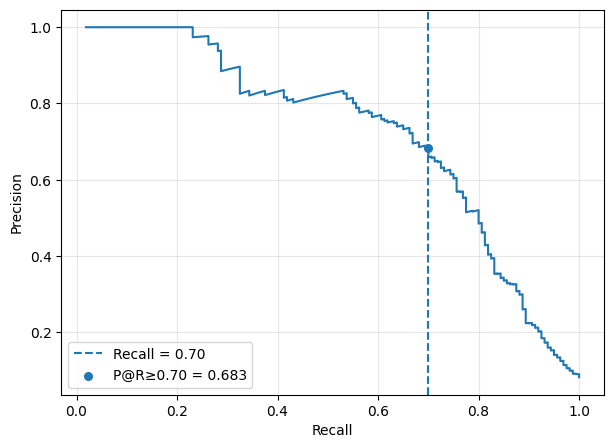

P@R>=0.7: 0.6829
R@FPR<=0.01: 0.5312
Mean P@R>=0.7: 0.6243
Std P@R>=0.7: 0.064
Min P@R>=0.7: 0.5316


In [70]:
is_valid = train.window_start_ts.ge('2026-04-17').values
pointer_cols = [
    'pointer_present_ratio',
    'pointer_any',
    'pointer_all',
    'pointer_distance_mean',
    'pointer_distance_median',
    'pointer_distance_std',
    'pointer_x_unique_ratio',
    'pointer_y_unique_ratio',
]

model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=random_state
)

p_at_r, r_at_fpr = validate_model(
    model,
    Xtr_pointer,
    ytr_pointer,
    is_valid,
    pointer_cols + diversity_cols + time_cols + cols
)

print('P@R>=0.7:', round(p_at_r, 4))
print('R@FPR<=0.01:', round(r_at_fpr, 4))

mean_score, std_score, min_score = validate_temporal(
    model,
    Xtr_pointer,
    ytr_pointer,
    pointer_cols + diversity_cols + time_cols + cols
)

print('Mean P@R>=0.7:', round(mean_score, 4))
print('Std P@R>=0.7:', round(std_score, 4))
print('Min P@R>=0.7:', round(min_score, 4))

## VI. Сравнение моделей

In [75]:
all_cols = cols + time_cols + diversity_cols + pointer_cols
Xtr_all, Xte_all, ytr_all = Xtr_pointer, Xte_pointer, ytr_pointer

In [76]:
models = {}

### o. Baseline

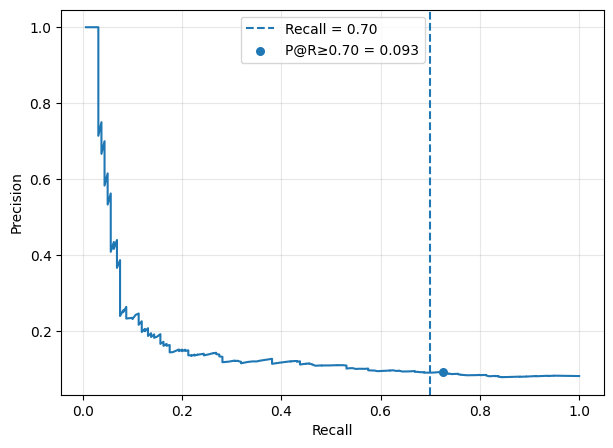

P@R>=0.7: 0.0931
R@FPR<=0.01: 0.0688
Mean P@R>=0.7: 0.0999
Std P@R>=0.7: 0.0152
Min P@R>=0.7: 0.0823


In [77]:
is_valid = train.window_start_ts.ge('2026-04-17').values

model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=random_state
)

p_at_r, r_at_fpr = validate_model(
    model,
    Xtr,
    ytr,
    is_valid,
    cols
)

print('P@R>=0.7:', round(p_at_r, 4))
print('R@FPR<=0.01:', round(r_at_fpr, 4))

mean_score, std_score, min_score = validate_temporal(
    model,
    Xtr,
    ytr,
    cols
)

print('Mean P@R>=0.7:', round(mean_score, 4))
print('Std P@R>=0.7:', round(std_score, 4))
print('Min P@R>=0.7:', round(min_score, 4))

In [78]:
models['Baseline'] = {
    'model': model,
    'mean_p_at_r': mean_score,
    'std_p_at_r': std_score,
    'min_p_at_r': min_score
}

### i. RandomForest

In [79]:
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3, 5],
}

results = []

for n_estimators, max_depth, min_samples_leaf in product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['min_samples_leaf']
):
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=-1
    )

    p_at_r, r_at_fpr = validate_model(
        model,
        Xtr_all,
        ytr_all,
        is_valid,
        all_cols,
        plot=False
    )

    results.append({
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_leaf': min_samples_leaf,
        'p_at_r': p_at_r,
        'r_at_fpr': r_at_fpr
    })

rf_results = pd.DataFrame(results).sort_values('p_at_r', ascending=False).reset_index(drop=True)
rf_results

,n_estimators,max_depth,min_samples_leaf,p_at_r,r_at_fpr
0,500,20.0,5,0.695652,0.46250
1,300,20.0,1,0.695652,0.50625
2,300,20.0,3,0.693252,0.45000
3,500,20.0,1,0.691358,0.48125
4,300,NaN,3,0.687117,0.45000
5,500,NaN,5,0.682927,0.46875
6,500,20.0,3,0.682927,0.45000
7,500,NaN,3,0.682927,0.45625
8,300,20.0,5,0.680723,0.45625
9,500,10.0,1,0.678788,0.48750


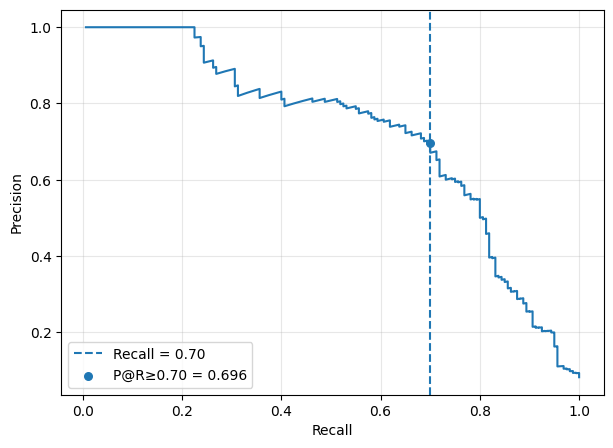

P@R>=0.7: 0.6957
Mean P@R>=0.7: 0.6405
Std P@R>=0.7: 0.0719
Min P@R>=0.7: 0.557


In [80]:
best = rf_results.iloc[0]

best_model = RandomForestClassifier(
    n_estimators=int(best['n_estimators']),
    max_depth=(None if pd.isna(best['max_depth']) else int(best['max_depth'])),
    min_samples_leaf=int(best['min_samples_leaf']),
    random_state=random_state,
    n_jobs=-1
)

p_at_r, r_at_fpr = validate_model(
    best_model,
    Xtr_all,
    ytr_all,
    is_valid,
    all_cols
)

mean_score, std_score, min_score = validate_temporal(
    best_model,
    Xtr_all,
    ytr_all,
    all_cols
)

print('P@R>=0.7:', round(p_at_r, 4))
print('Mean P@R>=0.7:', round(mean_score, 4))
print('Std P@R>=0.7:', round(std_score, 4))
print('Min P@R>=0.7:', round(min_score, 4))

In [81]:
models['RandomForest'] = {
    'model': best_model,
    'mean_p_at_r': mean_score,
    'std_p_at_r': std_score,
    'min_p_at_r': min_score
}

### ii. CatBoost

In [82]:
param_grid = {
    'iterations': [300, 500, 800],
    'depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05],
}

results = []

for iterations, depth, learning_rate in product(
    param_grid['iterations'],
    param_grid['depth'],
    param_grid['learning_rate']
):
    model = CatBoostClassifier(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=3,
        loss_function='Logloss',
        random_seed=random_state,
        verbose=False
    )

    p_at_r, r_at_fpr = validate_model(
        model,
        Xtr_all,
        ytr_all,
        is_valid,
        all_cols,
        plot=False
    )

    results.append({
        'iterations': iterations,
        'depth': depth,
        'learning_rate': learning_rate,
        'p_at_r': p_at_r,
        'r_at_fpr': r_at_fpr
    })

catboost_results = pd.DataFrame(results).sort_values('p_at_r', ascending=False).reset_index(drop=True)
catboost_results

,iterations,depth,learning_rate,p_at_r,r_at_fpr
0,300,6,0.05,0.741722,0.53125
1,300,6,0.03,0.727273,0.50625
2,500,5,0.03,0.722581,0.50000
3,500,4,0.05,0.715190,0.49375
4,500,6,0.03,0.708861,0.51250
5,800,5,0.03,0.704403,0.51250
6,800,6,0.03,0.704403,0.51250
7,800,4,0.05,0.701863,0.50000
8,500,4,0.03,0.695652,0.47500
9,800,5,0.05,0.691358,0.50625


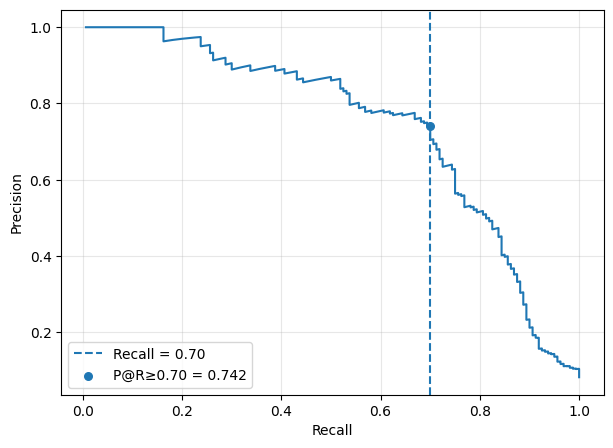

P@R>=0.7: 0.7417
Mean P@R>=0.7: 0.6798
Std P@R>=0.7: 0.0828
Min P@R>=0.7: 0.5522


In [83]:
best = catboost_results.iloc[0]

best_model = CatBoostClassifier(
    iterations=int(best['iterations']),
    depth=int(best['depth']),
    learning_rate=float(best['learning_rate']),
    l2_leaf_reg=3,
    loss_function='Logloss',
    random_seed=random_state,
    verbose=False
)

p_at_r, r_at_fpr = validate_model(
    best_model,
    Xtr_all,
    ytr_all,
    is_valid,
    all_cols
)

mean_score, std_score, min_score = validate_temporal(
    best_model,
    Xtr_all,
    ytr_all,
    all_cols
)

print('P@R>=0.7:', round(p_at_r, 4))
print('Mean P@R>=0.7:', round(mean_score, 4))
print('Std P@R>=0.7:', round(std_score, 4))
print('Min P@R>=0.7:', round(min_score, 4))

In [84]:
models['CatBoost'] = {
    'model': best_model,
    'mean_p_at_r': mean_score,
    'std_p_at_r': std_score,
    'min_p_at_r': min_score
}

### iii. LightGBM

In [85]:
param_grid = {
    'n_estimators': [300, 500, 800],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05],
}

results = []

for n_estimators, max_depth, learning_rate in product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['learning_rate']
):
    model = LGBMClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=random_state,
        verbosity=-1,
        n_jobs=-1
    )

    p_at_r, r_at_fpr = validate_model(
        model,
        Xtr_all,
        ytr_all,
        is_valid,
        all_cols,
        plot=False
    )

    results.append({
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'p_at_r': p_at_r,
        'r_at_fpr': r_at_fpr
    })

lightgbm_results = pd.DataFrame(results).sort_values('p_at_r', ascending=False).reset_index(drop=True)
lightgbm_results

,n_estimators,max_depth,learning_rate,p_at_r,r_at_fpr
0,300,8,0.03,0.708861,0.54375
1,500,4,0.03,0.700000,0.55625
2,300,4,0.03,0.687117,0.53125
3,300,4,0.05,0.684848,0.55000
4,500,8,0.03,0.684848,0.56250
5,300,6,0.03,0.682927,0.56250
6,800,4,0.05,0.678788,0.55000
7,300,6,0.05,0.662722,0.54375
8,300,8,0.05,0.662722,0.54375
9,500,6,0.03,0.654971,0.55625


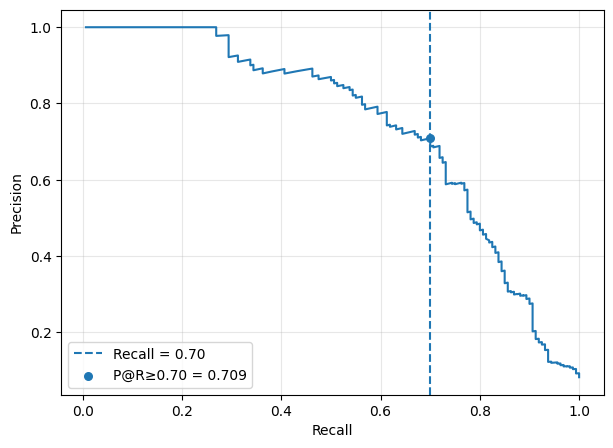

P@R>=0.7: 0.7089
Mean P@R>=0.7: 0.6902
Std P@R>=0.7: 0.0598
Min P@R>=0.7: 0.6


In [86]:
best = lightgbm_results.iloc[0]

best_model = LGBMClassifier(
    n_estimators=int(best['n_estimators']),
    max_depth=int(best['max_depth']),
    learning_rate=float(best['learning_rate']),
    random_state=random_state,
    verbosity=-1,
    n_jobs=-1
)

p_at_r, r_at_fpr = validate_model(
    best_model,
    Xtr_all,
    ytr_all,
    is_valid,
    all_cols
)

mean_score, std_score, min_score = validate_temporal(
    best_model,
    Xtr_all,
    ytr_all,
    all_cols
)

print('P@R>=0.7:', round(p_at_r, 4))
print('Mean P@R>=0.7:', round(mean_score, 4))
print('Std P@R>=0.7:', round(std_score, 4))
print('Min P@R>=0.7:', round(min_score, 4))

In [87]:
models['LightGBM'] = {
    'model': best_model,
    'mean_p_at_r': mean_score,
    'std_p_at_r': std_score,
    'min_p_at_r': min_score
}

### iv. XGBoost

In [88]:
param_grid = {
    'n_estimators': [300, 500, 800],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05],
}

results = []

for n_estimators, max_depth, learning_rate in product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['learning_rate']
):
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=random_state,
        n_jobs=-1
    )

    p_at_r, r_at_fpr = validate_model(
        model,
        Xtr_all,
        ytr_all,
        is_valid,
        all_cols,
        plot=False
    )

    results.append({
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'p_at_r': p_at_r,
        'r_at_fpr': r_at_fpr
    })

xgboost_results = pd.DataFrame(results).sort_values('p_at_r', ascending=False).reset_index(drop=True)
xgboost_results

,n_estimators,max_depth,learning_rate,p_at_r,r_at_fpr
0,500,6,0.03,0.687117,0.53750
1,300,6,0.03,0.684848,0.51875
2,800,6,0.03,0.678788,0.53750
3,300,4,0.05,0.676647,0.53125
4,800,4,0.05,0.674699,0.51250
5,300,6,0.05,0.674699,0.54375
6,300,4,0.03,0.670659,0.50625
7,800,4,0.03,0.670659,0.53750
8,500,4,0.03,0.662722,0.52500
9,500,4,0.05,0.660920,0.51250


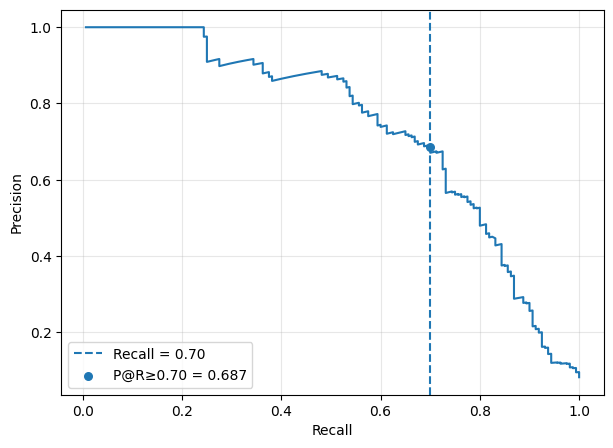

P@R>=0.7: 0.6871
Mean P@R>=0.7: 0.6597
Std P@R>=0.7: 0.0633
Min P@R>=0.7: 0.5588


In [89]:
best = xgboost_results.iloc[0]

best_model = XGBClassifier(
    n_estimators=int(best['n_estimators']),
    max_depth=int(best['max_depth']),
    learning_rate=float(best['learning_rate']),
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=random_state,
    n_jobs=-1
)

p_at_r, r_at_fpr = validate_model(
    best_model,
    Xtr_all,
    ytr_all,
    is_valid,
    all_cols
)

mean_score, std_score, min_score = validate_temporal(
    best_model,
    Xtr_all,
    ytr_all,
    all_cols
)

print('P@R>=0.7:', round(p_at_r, 4))
print('Mean P@R>=0.7:', round(mean_score, 4))
print('Std P@R>=0.7:', round(std_score, 4))
print('Min P@R>=0.7:', round(min_score, 4))

In [90]:
models['XGBoost'] = {
    'model': best_model,
    'mean_p_at_r': mean_score,
    'std_p_at_r': std_score,
    'min_p_at_r': min_score
}

### v. Сравнение моделей

In [91]:
model_results = pd.DataFrame({
    name: {
        'mean': info['mean_p_at_r'],
        'std': info['std_p_at_r'],
        'min': info['min_p_at_r']
    }
    for name, info in models.items()
}).T

model_results

,mean,std,min
Baseline,0.099949,0.015184,0.082324
RandomForest,0.640457,0.071921,0.556962
CatBoost,0.679796,0.082813,0.552239
LightGBM,0.690238,0.059790,0.600000
XGBoost,0.659720,0.063297,0.558824


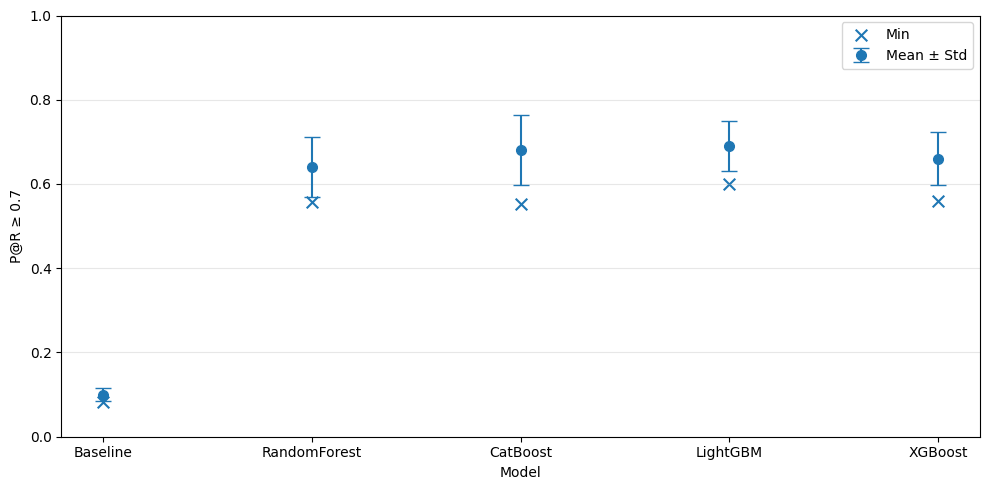

In [92]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(model_results))

ax.errorbar(
    x,
    model_results['mean'],
    yerr=model_results['std'],
    fmt='o',
    capsize=6,
    markersize=7,
    label='Mean ± Std'
)

ax.scatter(
    x,
    model_results['min'],
    marker='x',
    s=70,
    label='Min'
)

ax.set_xticks(x)
ax.set_xticklabels(model_results.index, rotation=0)

ax.set_ylabel('P@R ≥ 0.7')
ax.set_xlabel('Model')
ax.set_ylim(0, 1)

ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Среди рассмотренных моделей наилучший результат по временной валидации показал `LightGBM`, среднее значение `P@R≥0.7` составило `0.6902`. Кроме того, `LightGBM` продемонстрировал наибольшую устойчивость: стандартное отклонение составило `0.0598`, а минимальное значение метрики среди временных разбиений `0.6000`.

`CatBoost` показал наилучший результат на отдельном валидационном разбиении (`P@R≥0.7 = 0.7417`), однако на временной валидации его среднее качество ниже (`0.6798`), а разброс выше (`0.0828`).

`RandomForest` и `XGBoost` показали более низкое среднее качество на временной валидации `0.6405` и `0.6597` соответственно.

Таким образом, для итогового решения был выбран `LightGBM`, так как он показывает наиболее высокое среднее качество на временной валидации и при этом сохраняет более стабильные результаты на различных временных периодах.

## VII. Сабмит

In [96]:
best = lightgbm_results.iloc[0]

model = LGBMClassifier(
    n_estimators=int(best['n_estimators']),
    max_depth=int(best['max_depth']),
    learning_rate=float(best['learning_rate']),
    random_state=random_state,
    verbosity=-1,
    n_jobs=-1
)

model.fit(Xtr_all[all_cols], ytr_all)
sub = pd.DataFrame({
    'cookie_id': Xte_all.cookie_id,
    'score': model.predict_proba(Xte_all[all_cols])[:, 1],
})
assert len(sub) == len(test) and sub.score.between(0, 1).all()
sub.to_csv('submission.csv', index=False)
sub.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.000485
1,ck_a76ee3b3e3e522fd,0.078475
2,ck_94c9a4d382689e82,0.031125
3,ck_8eaf9509ad9462a0,0.001117
4,ck_9a88a5a989cb5bc6,0.015009
